<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/Collapse003.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

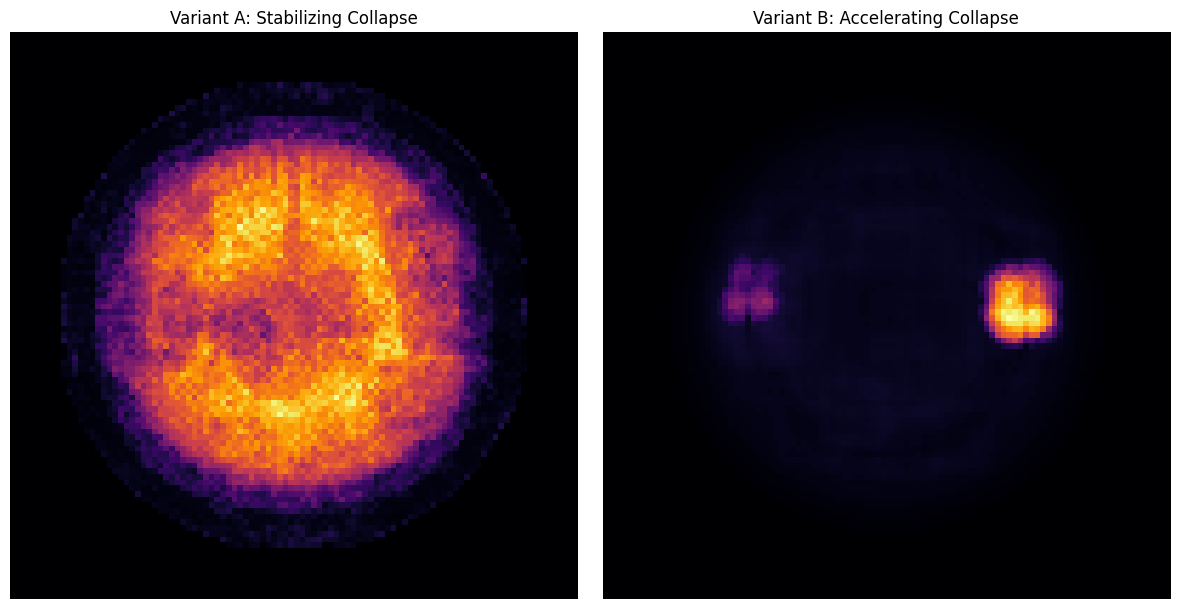

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
N = 100
timesteps = 500
alpha = 2.0
beta = 0.1
particle_count = 50
feedback_radius = 5

# Shell entropy field
def shell_entropy(N):
    x = np.linspace(-1, 1, N)
    grid = np.meshgrid(x, x, x)
    r = np.sqrt(sum(g**2 for g in grid))
    return np.exp(-((r - 0.5)**2) * 20)

# Initialize particles near shell ring
def initialize_particles(N, count):
    particles = []
    for _ in range(count):
        theta = np.random.uniform(0, 2*np.pi)
        phi = np.random.uniform(0, np.pi)
        r = 0.5
        x = int(N//2 + r * N//2 * np.sin(phi) * np.cos(theta))
        y = int(N//2 + r * N//2 * np.sin(phi) * np.sin(theta))
        z = int(N//2 + r * N//2 * np.cos(phi))
        particles.append([x, y, z])
    return np.array(particles)

# Apply feedback modulation
def apply_feedback(entropy, particles, variant):
    feedback = np.ones_like(entropy)
    for px, py, pz in particles:
        x_min = max(px - feedback_radius, 0)
        x_max = min(px + feedback_radius + 1, N)
        y_min = max(py - feedback_radius, 0)
        y_max = min(py + feedback_radius + 1, N)
        z_min = max(pz - feedback_radius, 0)
        z_max = min(pz + feedback_radius + 1, N)
        if variant == 'A':
            feedback[x_min:x_max, y_min:y_max, z_min:z_max] *= 0.9
        elif variant == 'B':
            feedback[x_min:x_max, y_min:y_max, z_min:z_max] *= 1.1
    return feedback

# Update particle positions
def update_particles(particles):
    for i in range(len(particles)):
        particles[i] += np.random.randint(-1, 2, size=3)
        particles[i] = np.clip(particles[i], 0, N-1)
    return particles

# Collapse simulation
def simulate_variant(variant):
    entropy = shell_entropy(N)
    particles = initialize_particles(N, particle_count)
    collapsed = np.zeros_like(entropy)
    entropy_retention = []
    correlation = []

    for t in range(timesteps):
        gradient = np.gradient(entropy)
        magnitude = np.sqrt(sum(g**2 for g in gradient))
        non_zero_mag = magnitude[magnitude > 1e-9]
        if non_zero_mag.size == 0:
            break
        mu_grad = np.mean(non_zero_mag)
        sigma_grad = np.std(non_zero_mag)
        adaptive_threshold = alpha * mu_grad + beta * sigma_grad
        collapse_mask = magnitude > adaptive_threshold

        feedback = apply_feedback(entropy, particles, variant)
        entropy[collapse_mask] *= 0.9 * feedback[collapse_mask]
        collapsed += collapse_mask.astype(float)

        entropy_retention.append(np.sum(entropy))
        correlation.append(np.mean(feedback[collapse_mask]) if np.any(collapse_mask) else 1.0)
        particles = update_particles(particles)

        if np.sum(entropy) < 1e-6:
            break

    return collapsed, entropy_retention, correlation

# Run both variants
collapsed_A, retention_A, corr_A = simulate_variant('A')
collapsed_B, retention_B, corr_B = simulate_variant('B')

# Plot results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(np.sum(collapsed_A, axis=0), cmap='inferno')
plt.title("Variant A: Stabilizing Collapse")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(np.sum(collapsed_B, axis=0), cmap='inferno')
plt.title("Variant B: Accelerating Collapse")
plt.axis('off')

plt.tight_layout()
plt.show()
